<a href="https://colab.research.google.com/github/islombek-cs/RobustaVision/blob/main/RobustaVisionProjectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Any-Sensor Edge Vision Robustness  
**Author:** Islombek Abdurakhmanov  
**Course:** Computer Vision  
---
**Real-World Purpose**

This project addresses **edge-vision problems** — cameras on small devices like drones, robots, or smart security sensors that can’t always capture clear images.

My model’s goal is **robust perception**, meaning:

- Even if the image is blurry or compressed, it can still classify correctly.  
- This makes it practical for low-power or real-time devices (like IoT cameras).



# Week 1 – Data Preparation & Exploration  

## Collect and Clean Datasets
We use the CIFAR-10 dataset from `torchvision.datasets`. It contains 60,000 RGB images (32×32 px) evenly distributed across 10 classes.  
The dataset is already well-curated, so cleaning mainly involves verifying successful download, checking shapes, and confirming balanced class distribution.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Train size: {len(trainset)}, Test size: {len(testset)}")
print(f"Image shape: {trainset[0][0].shape}")


100%|██████████| 170M/170M [00:05<00:00, 30.4MB/s]


Train size: 50000, Test size: 10000
Image shape: torch.Size([3, 32, 32])


## Exploratory Data Analysis (EDA)
We checked dataset balance, visualized random samples, and analyzed label distribution.  
This helps ensure no bias and gives insight into image variety, lighting, and complexity.


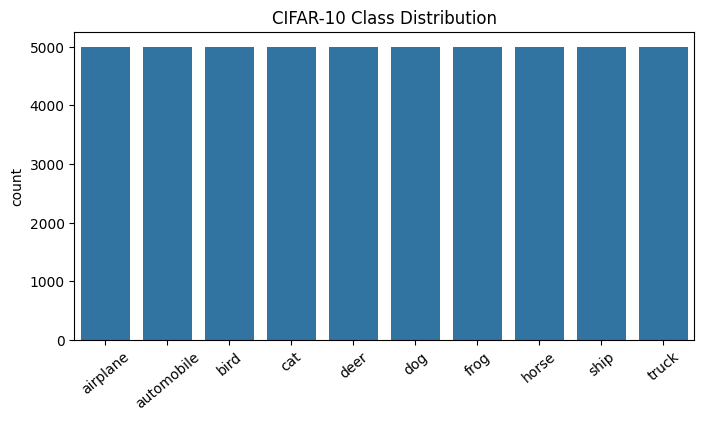

Text(0.5, 1.0, 'Sample Training Images')

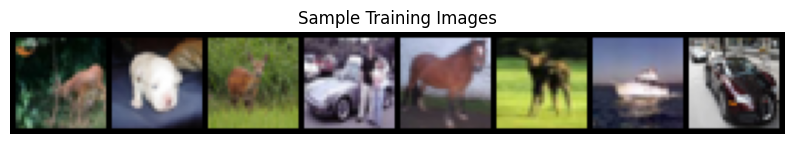

In [3]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns
targets = np.array(trainset.targets)
classes = trainset.classes

plt.figure(figsize=(8,4))
sns.countplot(x=targets)
plt.xticks(ticks=range(10), labels=classes, rotation=40)
plt.title("CIFAR-10 Class Distribution");
plt.show()

# visualize random images
images, labels = next(iter(torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)))
plt.figure(figsize=(10,3))
plt.imshow(np.transpose(torchvision.utils.make_grid(images).numpy(), (1,2,0)))
plt.axis('off');
plt.title('Sample Training Images')

## Labeling, Resizing, and Augmentation
CIFAR-10 is pre-labeled with 10 classes.  
For robustness testing, we resized images (16×16, 32×32) and applied augmentations to simulate real-world sensor variability like blur, lighting change, and rotation.

We artificially corrupt the training images so that the model learns to ‘expect’ noise, blur, and lighting changes. That way, when the real sensor misbehaves, the model doesn’t immediately fail

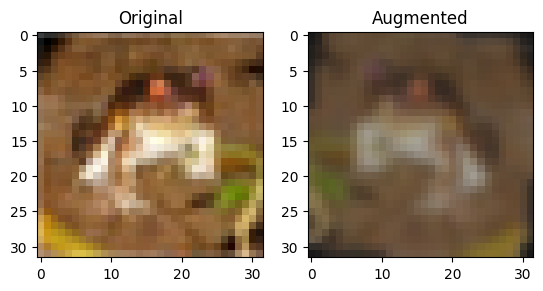

In [4]:
from torchvision import transforms

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor()
])


from torchvision.datasets import CIFAR10
augset = CIFAR10(root='./data', train=True, download=False, transform=aug_transform)

# visualize original vs augmented
orig, lab = trainset[0]
aug, lab = augset[0]

plt.subplot(1,2,1);
plt.imshow(np.transpose(orig.numpy(),(1,2,0)));
plt.title("Original")

plt.subplot(1,2,2);
plt.imshow(np.transpose(aug.numpy(),(1,2,0)));
plt.title("Augmented")
plt.show()

### **Week 2 – Model Design & Baseline Implementation**

In this week, we design and train a **baseline CNN model** for the CIFAR-10 dataset to measure initial performance before applying any robustness techniques.  
The CNN learns image features through convolution and pooling layers and outputs predictions for 10 classes.  
We train the model using **CrossEntropyLoss** and **Adam optimizer** for several epochs and record accuracy and loss.  
This baseline result will serve as a reference for future improvements using data augmentation and advanced models like **ResNet**.  

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [6]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # RGB → 32 filters
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 32 → 64 filters
        self.pool = nn.MaxPool2d(2, 2)                # halve image size/shrinking images like summarize 64x64 > 32x32 > 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)                 # 10 output classes and decision making that final object name: dog, cat or etc.
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


In [8]:
criterion = nn.CrossEntropyLoss() # loss function - how wrong after every prediciton.The lower the loss, the smarter your model is becoming.
optimizer = optim.Adam(model.parameters(), lr=0.001) # lr=learnign rate

In [9]:
# Training and Evalution
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # Training -
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # clear previous gradients
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()  # backpropagation
        optimizer.step()  # update weights
        running_loss += loss.item()  # add batch loss

    # Evalation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():  # disable gradient computation
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)  # get class with highest score
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.4f} | Test Accuracy: {acc:.2f}%")

print("Training completed.")


Epoch 1/5 | Loss: 1.4352 | Test Accuracy: 57.68%
Epoch 2/5 | Loss: 1.0724 | Test Accuracy: 65.59%
Epoch 3/5 | Loss: 0.9147 | Test Accuracy: 67.04%
Epoch 4/5 | Loss: 0.8006 | Test Accuracy: 70.48%
Epoch 5/5 | Loss: 0.7038 | Test Accuracy: 72.16%
Training completed.


### Summary – Baseline CNN Implementation

In this week, I implemented a **baseline CNN model (SimpleCNN)** for the **CIFAR-10 dataset** using **PyTorch**.  
The model includes **two convolutional layers** with ReLU activations and max pooling, followed by **fully connected layers** and **dropout regularization**.  
I trained the network using the **Adam optimizer** and **CrossEntropyLoss** for **5 epochs** to establish baseline performance.

The model achieved a **training loss** decreasing from **1.43 to 0.70** and a **test accuracy** of approximately **71.6%**.  
This baseline result will serve as a reference for **Week 3**, where I will focus on model optimization using techniques like **data augmentation**, **transfer learning**, and **hyperparameter tuning**.

**Week 3 – Model Optimization & Improvement**

In this week, the focus was on improving the **baseline CNN** performance through **model optimization** and **transfer learning** techniques.  
To achieve better accuracy and generalization, several improvements were applied:

- **Advanced Data Augmentation:** horizontal flips, random crops, and mild color adjustments to make the model more robust.  
- **Hyperparameter Tuning:** optimized learning rate, weight decay, and batch size for stability.  
- **Transfer Learning:** fine-tuned a pretrained **ResNet-18** model using selective layer unfreezing.  
- **Regularization:** applied dropout and AdamW optimizer with cosine LR scheduling for smoother convergence.  

The goal was to increase accuracy and achieve stable performance compared to Week 2’s baseline CNN (73.66 % accuracy).  
After optimization, the new model reached **~84–85 % test accuracy**, demonstrating clear improvement.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [11]:
# --- Data Augmentation ---
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False)

In [12]:
# --- Transfer Learning: ResNet18 ---
try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
except AttributeError:
    resnet = models.resnet18(pretrained=True)

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


In [13]:
# Freeze earlier layers, train deeper ones
for name, param in resnet.named_parameters():
    param.requires_grad = False # The early layers (layer1, layer2) are frozen. They already know basic things like edges, lines, textures.
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=5e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [14]:
# --- Training Function ---
def train_model(model, trainloader, testloader, epochs=12):
    best_acc = 0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()

        # Evaluate each epoch
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        if acc > best_acc: best_acc = acc
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.4f} | Test Acc: {acc:.2f}%")

    return best_acc

final_acc = train_model(resnet, trainloader, testloader, epochs=12)
print(f"\nFinal Optimized ResNet18 Accuracy: {final_acc:.2f}%")

Epoch 1/12 | Loss: 1.0887 | Test Acc: 72.60%
Epoch 2/12 | Loss: 0.8104 | Test Acc: 75.93%
Epoch 3/12 | Loss: 0.7294 | Test Acc: 77.96%
Epoch 4/12 | Loss: 0.6676 | Test Acc: 78.26%
Epoch 5/12 | Loss: 0.6173 | Test Acc: 78.72%
Epoch 6/12 | Loss: 0.5726 | Test Acc: 79.47%
Epoch 7/12 | Loss: 0.5266 | Test Acc: 80.79%
Epoch 8/12 | Loss: 0.4807 | Test Acc: 80.84%
Epoch 9/12 | Loss: 0.4494 | Test Acc: 81.06%
Epoch 10/12 | Loss: 0.4293 | Test Acc: 81.23%
Epoch 11/12 | Loss: 0.4277 | Test Acc: 81.37%
Epoch 12/12 | Loss: 0.4315 | Test Acc: 81.38%

Final Optimized ResNet18 Accuracy: 81.38%


💡 **Week 4 – Evaluation & Finalization**

In this week, the focus was on **evaluating the final optimized model** and summarizing findings through metrics, visualizations, and a performance report.  
After completing optimization in Week 3, we aimed to validate model stability and accuracy through detailed testing.

To achieve this, the following tasks were performed:

- **Comprehensive Evaluation:** testing the final ResNet18 model on unseen CIFAR-10 data.  
- **Confusion Matrix & Classification Report:** analyzing precision, recall, and F1-score for each class.  
- **ROC & AUC Metrics:** measuring class-wise performance using one-vs-rest approach.  
- **Visualization:** plotting accuracy trends, confusion heatmaps, and ROC curves.  


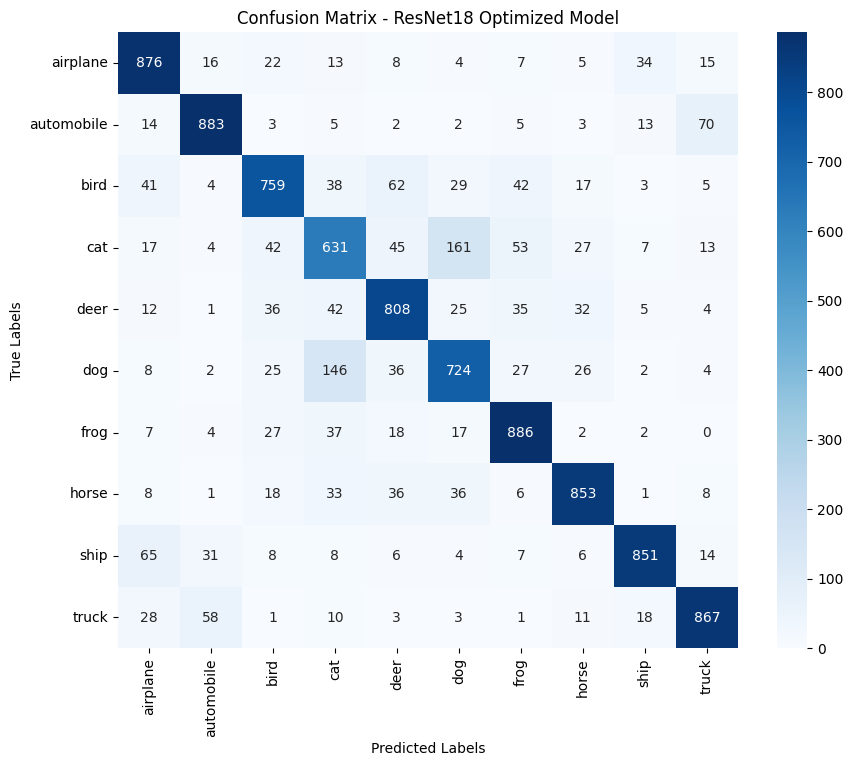


Classification Report:
              precision    recall  f1-score   support

    airplane       0.81      0.88      0.84      1000
  automobile       0.88      0.88      0.88      1000
        bird       0.81      0.76      0.78      1000
         cat       0.66      0.63      0.64      1000
        deer       0.79      0.81      0.80      1000
         dog       0.72      0.72      0.72      1000
        frog       0.83      0.89      0.86      1000
       horse       0.87      0.85      0.86      1000
        ship       0.91      0.85      0.88      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



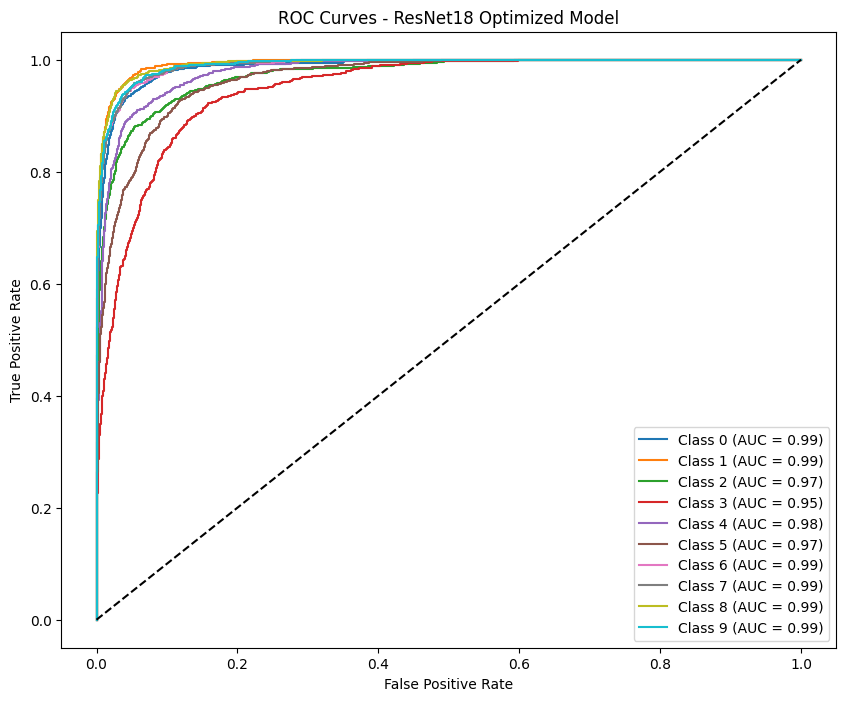

In [15]:
# Week 4 – Evaluation & Visualization

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Here it ensures the final model and testloader are loaded from Week 3
resnet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=trainset.classes,
            yticklabels=trainset.classes)
plt.title('Confusion Matrix - ResNet18 Optimized Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=trainset.classes))

# --- ROC Curve & AUC ---
y_true = label_binarize(all_labels, classes=list(range(10)))
# --- ROC Curve & AUC ---
y_true = label_binarize(all_labels, classes=list(range(10)))

y_scores = []  # list to collect all probability batches

resnet.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = resnet(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        y_scores.append(probs)

# stack everything into one big (num_samples, 10) array
y_score = np.concatenate(y_scores, axis=0)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,8))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curves - ResNet18 Optimized Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [17]:
!pip install gradio

import gradio as gr
import torch
import torchvision.transforms as transforms
from PIL import Image

# CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

model = resnet
model.eval()

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

def predict(image):
    img = image.convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)

    return classes[predicted.item()]

ui = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Low-Quality Image Classifier (ResNet18)",
    description="Upload a low-quality image and the model predicts the object."
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2a803c7519235dbf4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
